# 02. Data Preprocessing
Melakukan tahapan preprocessing:
1. **Drop Variabel**: `Age` dan `Owner_Gender`.
2. **Data Splitting**: Memisahkan data Train dan Test untuk mencegah *Data Leakage*.
3. **Normalisasi Distribusi Data**: Scaling pada data Train, lalu *apply* ke data Test.
4. **Handling Imbalanced Data**: *Oversampling* dengan SMOTE (HANYA PADA DATA TRAIN).

In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import joblib

# Konfigurasi path dinamis
BASE_DIR = Path.cwd().parent.resolve()
DATA_PATH = str(BASE_DIR / 'data' / 'umkm_success.csv')
RESULTS_PATH = str(BASE_DIR / 'results')

Path(RESULTS_PATH).mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

### 1. Drop Kolom yang Tidak Relevan

In [2]:
cols_to_drop = ['Age', 'Owner_Gender']
df_dropped = df.drop(columns=cols_to_drop)

print(f"Kolom yang didrop: {cols_to_drop}")
print(f"Bentuk data setelah drop: {df_dropped.shape}")

Kolom yang didrop: ['Age', 'Owner_Gender']
Bentuk data setelah drop: (250, 11)


### 2. Train-Test Split
Pemisahan data **harus dilakukan SEBELUM** normalisasi dan oversampling untuk mencegah **Data Leakage** (kebocoran informasi dari data testing ke model saat training).

In [3]:
X = df_dropped.drop(columns=['Success'])
y = df_dropped['Success']

# stratify=y memastikan rasio kesuksesan seimbang antara data train dan test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah data Training: {len(X_train)}")
print(f"Jumlah data Testing: {len(X_test)}")

Jumlah data Training: 200
Jumlah data Testing: 50


### 3. Normalisasi Data
`StandardScaler` hanya di-`fit` menggunakan data *Training*, lalu diduplikasi (`transform`) ke data *Testing*.

In [4]:
norm_cols = ['Industry_Experience', 'Education', 'Marketing_Effort', 'Professional_Advice']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# FIT & TRANSFORM hanya di X_TRAIN. 
# Di X_TEST hanya boleh TRANSFORM saja.
X_train_scaled[norm_cols] = scaler.fit_transform(X_train[norm_cols])
X_test_scaled[norm_cols] = scaler.transform(X_test[norm_cols])

# Simpan scaler
joblib.dump(scaler, f'{RESULTS_PATH}/scaler.pkl')
print("Normalisasi berhasil dan Scaler disimpan!")

Normalisasi berhasil dan Scaler disimpan!


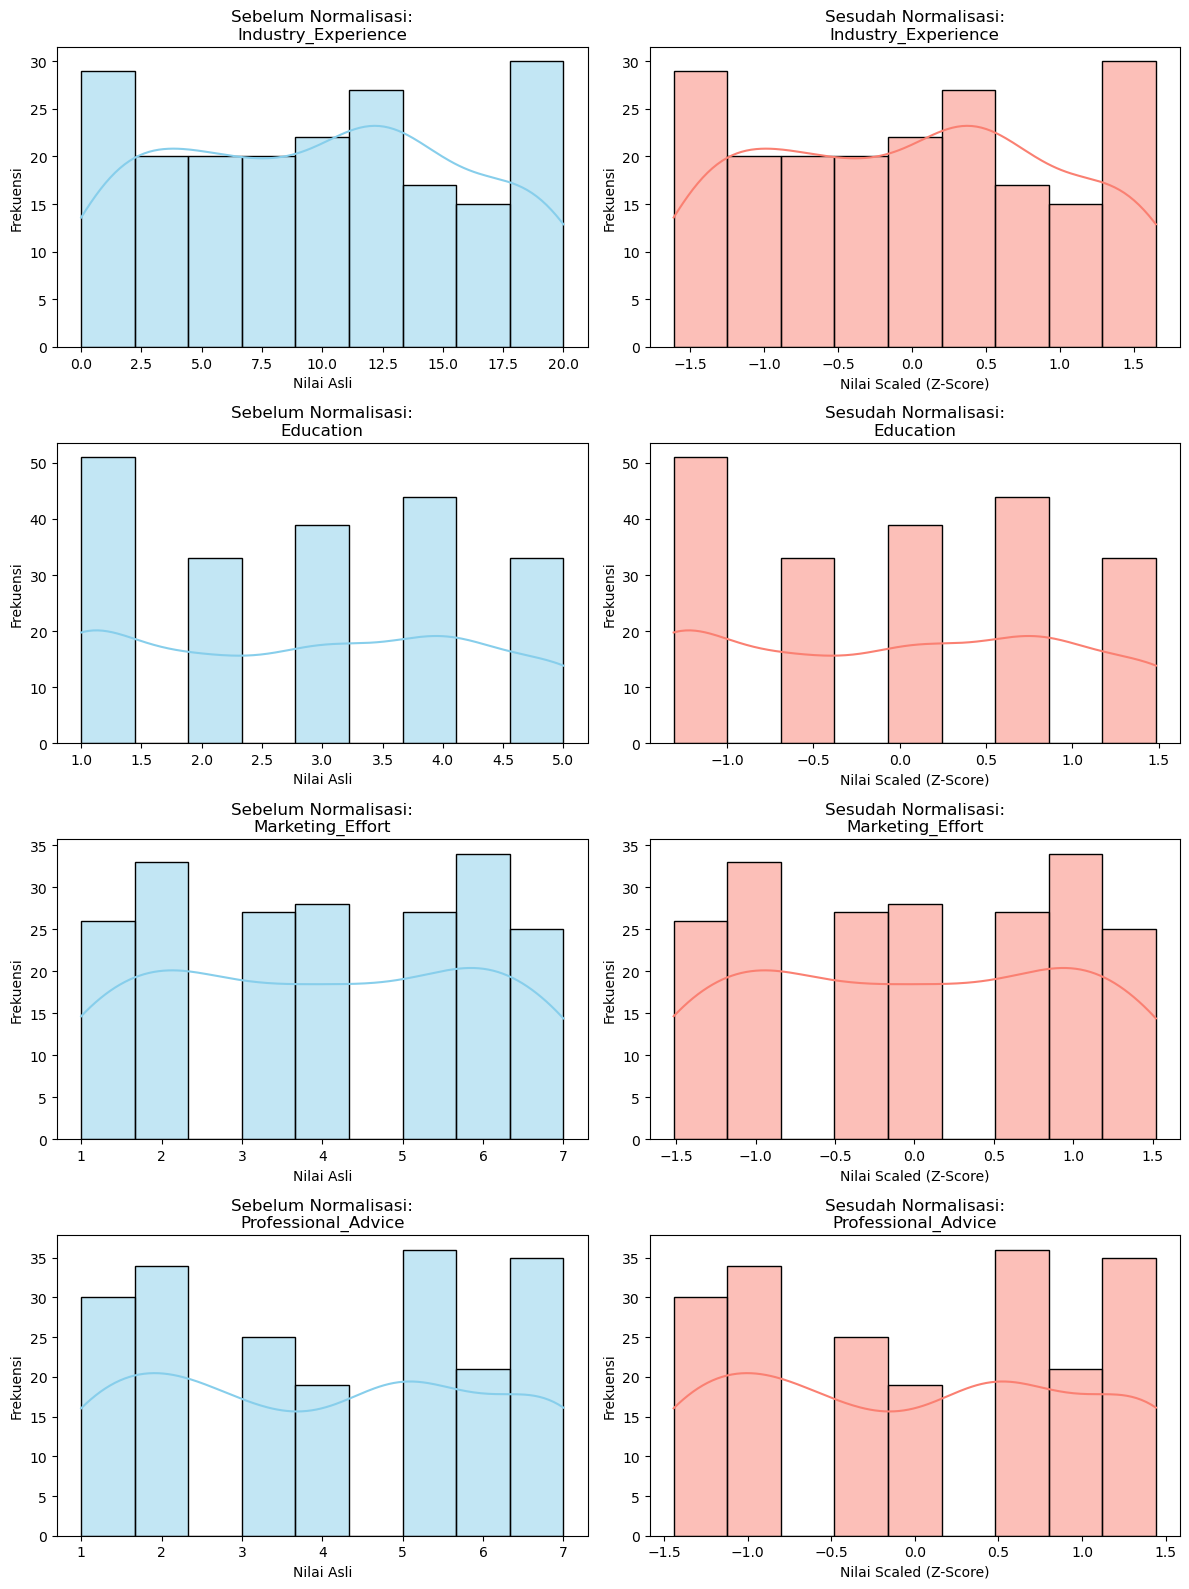

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan matplotlib dan seaborn sudah di-import
fig, axes = plt.subplots(nrows=len(norm_cols), ncols=2, figsize=(12, 4 * len(norm_cols)))

for i, col in enumerate(norm_cols):
    # Plot sebelum normalisasi (Data Asli dari X_train)
    sns.histplot(X_train[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Sebelum Normalisasi:\n{col}')
    axes[i, 0].set_xlabel('Nilai Asli')
    axes[i, 0].set_ylabel('Frekuensi')

    # Plot sesudah normalisasi (Data Scaled dari X_train_scaled)
    sns.histplot(X_train_scaled[col], kde=True, ax=axes[i, 1], color='salmon')
    axes[i, 1].set_title(f'Sesudah Normalisasi:\n{col}')
    axes[i, 1].set_xlabel('Nilai Scaled (Z-Score)')
    axes[i, 1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()
a

### 4. Penanganan Imbalanced Data (Oversampling)
SMOTE **HANYA** diaplikasikan pada data *Training*. Data *Testing* harus dibiarkan apa adanya (imbalanced) agar saat diuji, model menghadapi kondisi nyata.

In [6]:
print("--- Distribusi y_train SEBELUM SMOTE ---")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("\n--- Distribusi y_train SETELAH SMOTE ---")
print(y_train_resampled.value_counts())

# Test data tidak boleh diganggu
print("\n--- Distribusi y_test (MURNI TANPA SMOTE) ---")
print(y_test.value_counts())

--- Distribusi y_train SEBELUM SMOTE ---
Success
0    150
1     50
Name: count, dtype: int64

--- Distribusi y_train SETELAH SMOTE ---
Success
0    150
1    150
Name: count, dtype: int64

--- Distribusi y_test (MURNI TANPA SMOTE) ---
Success
0    38
1    12
Name: count, dtype: int64


### 5. Simpan Hasil Preprocessing

In [7]:
# Gabungkan kembali menjadi dua pasang: Train Data dan Test Data
train_preprocessed = pd.concat([X_train_resampled, y_train_resampled], axis=1)
test_preprocessed = pd.concat([X_test_scaled, y_test], axis=1)

train_file = f'{RESULTS_PATH}/train_preprocessed.csv'
test_file = f'{RESULTS_PATH}/test_preprocessed.csv'

train_preprocessed.to_csv(train_file, index=False)
test_preprocessed.to_csv(test_file, index=False)

print(f"Data Train bersih disimpan di: {train_file}")
print(f"Data Test bersih disimpan di: {test_file}")

Data Train bersih disimpan di: D:\naufalarizq\ipb\lomba\infest\results/train_preprocessed.csv
Data Test bersih disimpan di: D:\naufalarizq\ipb\lomba\infest\results/test_preprocessed.csv
